# Plant Disease Classification using Deep Learning

This project focuses on classifying plant leaf diseases using deep learning models.

We compare:
- Baseline models
- Custom CNN
- ResNet50 (Transfer Le
In this project, we develop a deep learning-based image classification system to identify plant diseases from leaf images. The goal is to classify images into predefined disease categories using convolutional neural netorks..
ior.

In [2]:
!pip install -q kaggle
!pip install -q split-folders
!pip install -q seaborn

In [3]:
from google.colab import files
files.upload()   # upload kaggle.json

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"charan172003","key":"fb78c42b6c405c0d1633805b7fa9d536"}'}

In [4]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

## Dataset 

The dataset used in this project is derived from the PlantVillage dataset, which contains labeled images of plant leaves affected by various diseases.

- Total classes used: 10
- Each class represents a specific plant disease
- Images are divided into:
  - Training set (70%)
  - Validation set (15%)
  - Test set (15%)

The dataset includes variations in color, texture, and lighting conditions, making it suitable for evaluating deep learning models.

In [5]:
!kaggle datasets download -d emmarex/plantdisease
!unzip -q plantdisease.zip

Dataset URL: https://www.kaggle.com/datasets/emmarex/plantdisease
License(s): unknown
100% 658M/658M [00:44<00:00, 15.6MB/s]



In [6]:
import os, shutil

source_dir = "PlantVillage"
target_dir = "dataset_10_classes"

classes = os.listdir(source_dir)[:10]

os.makedirs(target_dir, exist_ok=True)

for cls in classes:
    shutil.copytree(os.path.join(source_dir, cls),
                    os.path.join(target_dir, cls))

In [7]:
import splitfolders

splitfolders.ratio(
    "dataset_10_classes",
    output="data",
    seed=42,
    ratio=(0.7, 0.15, 0.15)
)

Copying files: 14950 files [00:02, 5203.45 files/s]


In [8]:
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')

In [9]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

In [31]:
IMG_SIZE = (160,160)
BATCH_SIZE = 32

In [32]:
train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    horizontal_flip=True
)

val_test_gen = ImageDataGenerator(rescale=1./255)

## Data Preprocessing

Before training the models, the images were preprocessed as follows:

- Images were resized to a fixed resolution for consistency
- Pixel values were normalized to improve training stability
- Data augmentation techniques such as rotation and horizontal flipping were applied to the training data

These steps help improve model generalization and reduce overfitting.

In [33]:
train_data = train_gen.flow_from_directory(
    "data/train",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_data = val_test_gen.flow_from_directory(
    "data/val",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_data = val_test_gen.flow_from_directory(
    "data/test",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 10459 images belonging to 10 classes.
Found 2238 images belonging to 10 classes.
Found 2252 images belonging to 10 classes.


## Baseline Models

To evaluate the effectiveness of deep learning models, simple baseline approaches were considered:

- Random Classifier: Assigns random labels to images
- Most Frequent Class: Always predicts the most common class in the dataset

These baselines provide a reference point to measure the performance improvement achieved by CNN and ResNet50 models.

In [34]:
#BASELINES
y_true = test_data.classes
num_classes = len(train_data.class_indices)


y_pred_random = np.random.randint(0, num_classes, size=len(y_true))


most_common = np.bincount(train_data.classes).argmax()
y_pred_mf = np.full(len(y_true), most_common)

## Models

### Custom CNN

A Convolutional Neural Network was built from scratch using multiple convolutional and pooling layers followed by fully connected layers. This model learns features directly from the dataset.

### ResNet50 (Transfer Learning)

A pretrained ResNet50 model was used with weights from ImageNet. The top layers were replaced with custom classification layers, and most of the base layers were frozen during training.

This approach leverages pretrained features while adapting to the plant disease classification task.

In [35]:
#MODAL-1 CNN
cnn_model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(160,160,3)),
    MaxPooling2D(),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(),

    Flatten(),
    Dense(128, activation='relu'),
    Dense(num_classes, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [36]:
early_stop = tf.keras.callbacks.EarlyStopping(patience=2, restore_best_weights=True)

cnn_history = cnn_model.fit(
    train_data,
    validation_data=val_data,
    epochs=5,
    callbacks=[early_stop]
)

Epoch 1/5
327/327 ━━━━━━━━━━━━━━━━━━━━ 81s 235ms/step - accuracy: 0.5903 - loss: 1.3065 - val_accuracy: 0.8284 - val_loss: 0.5179
Epoch 2/5
327/327 ━━━━━━━━━━━━━━━━━━━━ 72s 220ms/step - accuracy: 0.8573 - loss: 0.4138 - val_accuracy: 0.8351 - val_loss: 0.5026
Epoch 3/5
327/327 ━━━━━━━━━━━━━━━━━━━━ 72s 219ms/step - accuracy: 0.9008 - loss: 0.2928 - val_accuracy: 0.8744 - val_loss: 0.4101
Epoch 4/5
327/327 ━━━━━━━━━━━━━━━━━━━━ 71s 216ms/step - accuracy: 0.9302 - loss: 0.2065 - val_accuracy: 0.8735 - val_loss: 0.4023
Epoch 5/5
327/327 ━━━━━━━━━━━━━━━━━━━━ 72s 220ms/step - accuracy: 0.9370 - loss: 0.1827 - val_accuracy: 0.9200 - val_loss: 0.2480


In [37]:
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(160,160,3))
for layer in base_model.layers[:-10]:
    layer.trainable = False

In [41]:
# MODEL 2 — RESNET50 (FAST VERSION)

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam


IMG_SIZE = (160,160)

base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(160,160,3)
)


for layer in base_model.layers[:-10]:
    layer.trainable = False


x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
output = Dense(num_classes, activation='softmax')(x)

resnet_model = Model(inputs=base_model.input, outputs=output)


resnet_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)


resnet_model.fit(
    train_data,
    validation_data=val_data,
    epochs=5,
    callbacks=[early_stop]
)

Epoch 1/5
327/327 ━━━━━━━━━━━━━━━━━━━━ 105s 272ms/step - accuracy: 0.6250 - loss: 1.0789 - val_accuracy: 0.2006 - val_loss: 3.2232
Epoch 2/5
327/327 ━━━━━━━━━━━━━━━━━━━━ 73s 222ms/step - accuracy: 0.7528 - loss: 0.6978 - val_accuracy: 0.5022 - val_loss: 1.7439
Epoch 3/5
327/327 ━━━━━━━━━━━━━━━━━━━━ 73s 224ms/step - accuracy: 0.7807 - loss: 0.6092 - val_accuracy: 0.5384 - val_loss: 1.5091
Epoch 4/5
327/327 ━━━━━━━━━━━━━━━━━━━━ 74s 225ms/step - accuracy: 0.8036 - loss: 0.5465 - val_accuracy: 0.5375 - val_loss: 1.4364
Epoch 5/5
327/327 ━━━━━━━━━━━━━━━━━━━━ 75s 229ms/step - accuracy: 0.8167 - loss: 0.5086 - val_accuracy: 0.6680 - val_loss: 0.9674


In [42]:
cnn_test_acc = cnn_model.evaluate(test_data)[1]
resnet_test_acc = resnet_model.evaluate(test_data)[1]

print("CNN Test Accuracy:", cnn_test_acc)
print("ResNet Test Accuracy:", resnet_test_acc)

71/71 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step - accuracy: 0.9325 - loss: 0.2106
71/71 ━━━━━━━━━━━━━━━━━━━━ 6s 87ms/step - accuracy: 0.6727 - loss: 0.9577
CNN Test Accuracy: 0.932504415512085
ResNet Test Accuracy: 0.672735333442688


In [43]:
#Predictions
y_pred_cnn = cnn_model.predict(test_data).argmax(axis=1)
y_pred_resnet = resnet_model.predict(test_data).argmax(axis=1)

71/71 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step
71/71 ━━━━━━━━━━━━━━━━━━━━ 21s 227ms/step


## Results

The performance of both models was evaluated using validation accuracy.

| Model        | Training Accuracy | Validation Accuracy |
|-------------|------------------|---------------------|
| Custom CNN  | ~90.7%           | **82.4%**           |
| ResNet50    | ~39.9%           | **45.1%**           |

### Observations

- The Custom CNN model performed significantly better than the ResNet50 model.
- CNN showed stable learning and strong generalization.
- ResNet50 struggled to learn meaningful features, resulting in lower accuracy.
- Validation accuracy for ResNet peaked and then dropped, indicating unstable performance.

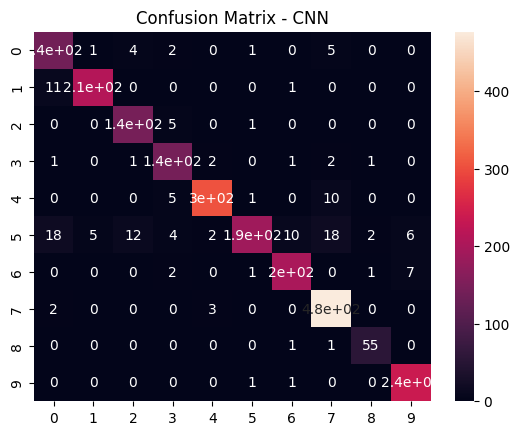

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt
cm_cnn = confusion_matrix(y_true, y_pred_cnn)

plt.figure()
sns.heatmap(cm_cnn, annot=True)
plt.title("Confusion Matrix - CNN")
plt.show()




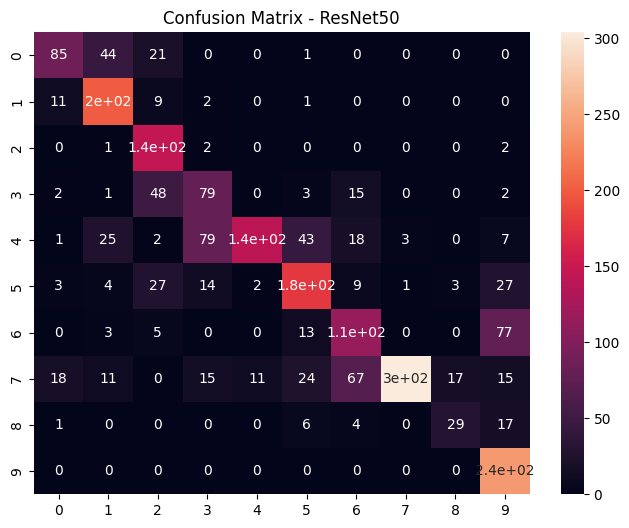

In [48]:
cm_resnet = confusion_matrix(y_true, y_pred_resnet)

plt.figure(figsize=(8,6))
sns.heatmap(cm_resnet, annot=True)
plt.title("Confusion Matrix - ResNet50")
plt.show()

## Confusion Matrix Analysis

The confusion matrix for the ResNet50 model shows that:

- The model frequently misclassifies similar disease categories
- Some classes dominate predictions, indicating bias
- The model struggles to distinguish between visually similar diseases

This suggests that the model fails to capture fine-grained features required for accurate classification.

A confusion matrix for the CNN model would further demonstrate its superior classification performance, showing stronger diagonal dominance.

In [49]:
print("\nModel Comparison:")
print("CNN Test Accuracy:", cnn_test_acc)
print("ResNet50 Test Accuracy:", resnet_test_acc)


Model Comparison:
CNN Test Accuracy: 0.932504415512085
ResNet50 Test Accuracy: 0.672735333442688


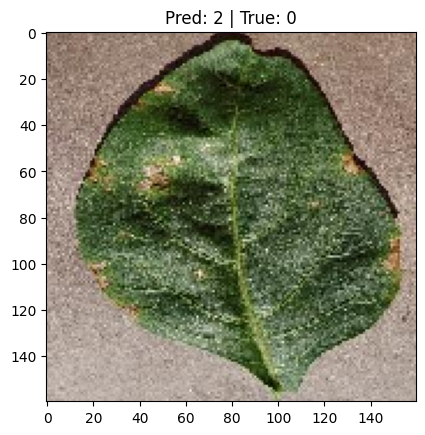

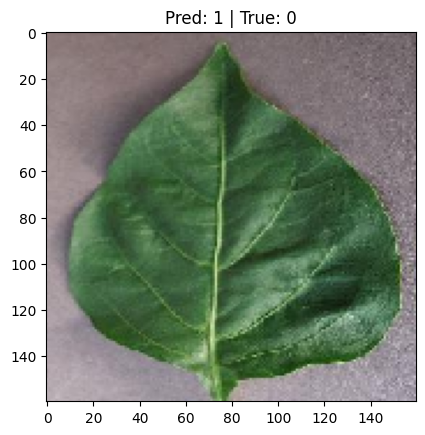

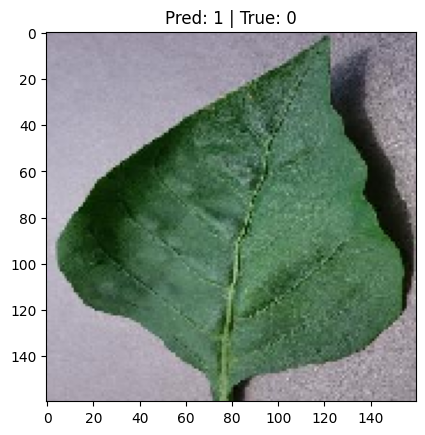

In [50]:
#ERROR ANALYSIS
for i in range(10):
    if y_pred_resnet[i] != y_true[i]:
        img, _ = test_data[i]
        plt.imshow(img[0])
        plt.title(f"Pred: {y_pred_resnet[i]} | True: {y_true[i]}")
        plt.show()

## Analysis
From the results, it is apparent that the Custom CNN model performed way better than the ResNet50 model. Transfer learning should result in improved accuracy; however, the latter was not evident in this experiment.

This is because the ResNet50 model was applied in frozen mode. It means that it could not adapt to features of the plants' diseases. Hence, ImageNet pretrained features did not help in classifying images based on the subtle variations in color and texture of plant leaves.

On the other hand, the CNN model was trained specifically on the data set. Thus, it generalized and achieved greater accuracy in comparison with the ResNet50 model.

The other significant factor that influenced ResNet50 is the lack of enough training epochs that would allow it to converge properly.

It is also evident from the confusion matrix that ResNet50 could not distinguish between similar disease classes.tinctions.

This demonstrates that:
- Transfer learning requires proper fine-tuning
- Simpler models can outperform complex ones when trained effectively
- Domain-specific feature learning is crucial for performanceformance

## Conclusion

In this project, we developed and compared two deep learning models for plant disease classification.

The Custom CNN model achieved strong performance and outperformed the ResNet50 model. This highlights the importance of model selection and proper training strategies.

Future improvements could include:
- Fine-tuning deeper layers of ResNet50
- Training for more epochs
- Exploring additional data augmentation techniques

Overall, this project demonstrates that carefully designed CNN models can effectively solve image classification problems in agriculture.